<a href="https://colab.research.google.com/github/irsyad-kamil/Final_Project_NLP/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup & Load Data

In [1]:
!pip install wordcloud nltk matplotlib seaborn pandas -q

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
from collections import Counter

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
!git clone https://github.com/irsyad-kamil/Final_Project_NLP.git
df = pd.read_csv('/content/Final_Project_NLP/tokopedia_product_reviews_2025.csv')

print(f"Shape: {df.shape}")
print(f"\nKolom: {df.columns.tolist()}")
print(f"\nSample data:")
df.head(3)

Shape: (65543, 13)

Kolom: ['review_text', 'review_date', 'review_id', 'product_name', 'product_category', 'product_variant', 'product_price', 'product_url', 'product_id', 'rating', 'sold_count', 'shop_id', 'sentiment_label']

Sample data:


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   26749 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB


## Data Overview

In [7]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).query('`Missing Count` > 0')

print("=== Missing Values ===")
print(missing_df)

=== Missing Values ===
                 Missing Count  Missing (%)
product_variant          38794        59.19


=== Distribusi Sentiment Label ===
  positive  : 63,943 (97.56%)
  neutral   :    802 (1.22%)
  negative  :    798 (1.22%)


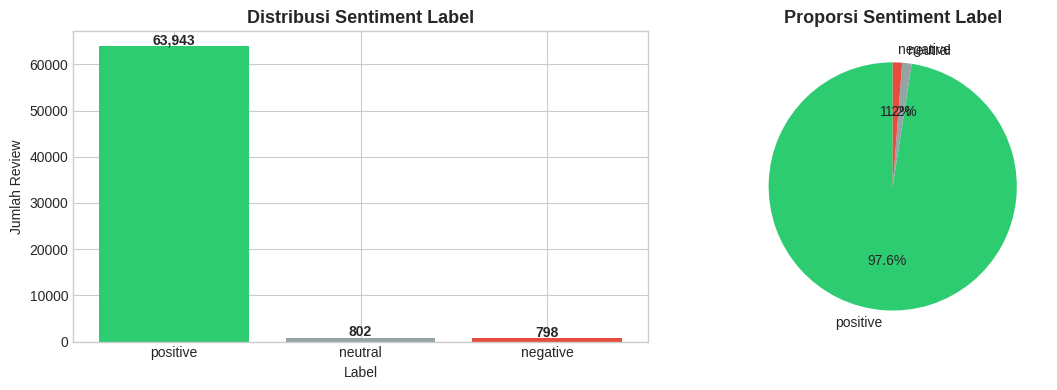

In [25]:
label_counts = df['sentiment_label'].value_counts()
label_pct = (label_counts / len(df) * 100).round(2)

print("=== Distribusi Sentiment Label ===")
for label, count in label_counts.items():
    print(f"  {label:10s}: {count:6,} ({label_pct[label]}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(label_counts.index, label_counts.values, color=['#2ecc71', '#95a5a6', '#e74c3c'])
axes[0].set_title('Distribusi Sentiment Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah Review')
for i, (label, val) in enumerate(label_counts.items()):
    axes[0].text(i, val + 300, f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#95a5a6', '#e74c3c'],
            startangle=90)
axes[1].set_title('Proporsi Sentiment Label', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

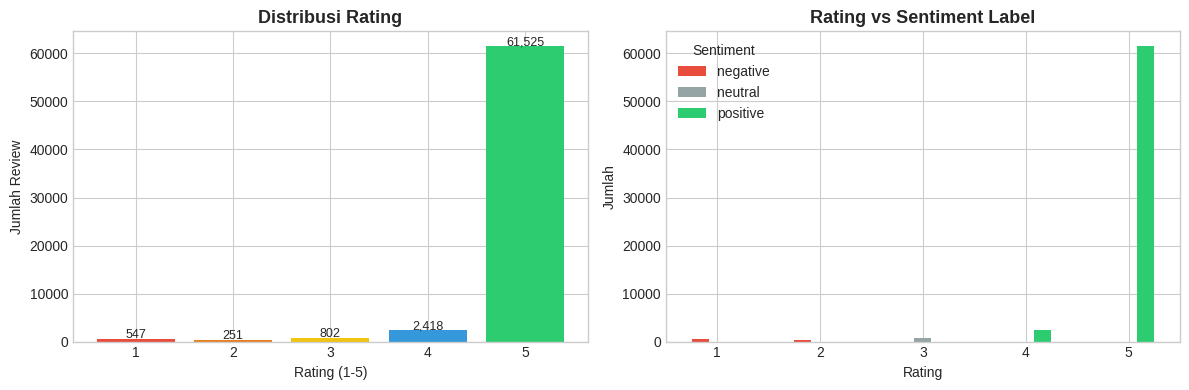

In [12]:
rating_counts = df['rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart rating
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#2ecc71']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors)
axes[0].set_title('Distribusi Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (1-5)')
axes[0].set_ylabel('Jumlah Review')
for i, (rating, val) in enumerate(rating_counts.items()):
    axes[0].text(rating, val + 200, f'{val:,}', ha='center', fontsize=9)

# Rating vs Sentiment (heatmap-style)
cross = pd.crosstab(df['rating'], df['sentiment_label'])
cross.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[1].set_title('Rating vs Sentiment Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Jumlah')
axes[1].legend(title='Sentiment')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

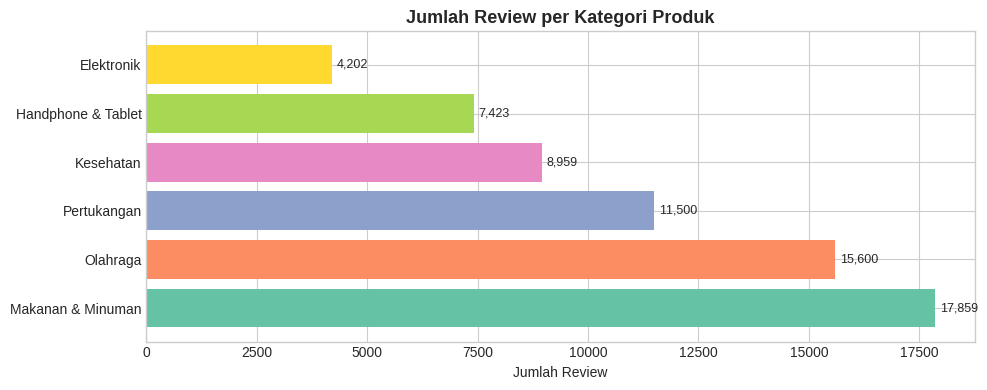

In [11]:
cat_counts = df['product_category'].value_counts()

plt.figure(figsize=(10, 4))
bars = plt.barh(cat_counts.index, cat_counts.values, color=sns.color_palette("Set2", len(cat_counts)))
plt.title('Jumlah Review per Kategori Produk', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Review')
for bar, val in zip(bars, cat_counts.values):
    plt.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Text Analysis

In [13]:
df['text_length'] = df['review_text'].astype(str).apply(len)
df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))
df['has_uppercase'] = df['review_text'].astype(str).apply(lambda x: any(c.isupper() for c in x))
df['exclamation_count'] = df['review_text'].astype(str).apply(lambda x: x.count('!'))

print("=== Statistik Panjang Teks per Label ===")
print(df.groupby('sentiment_label')[['text_length', 'word_count']].describe().round(2))

=== Statistik Panjang Teks per Label ===
                text_length                                                   \
                      count    mean     std  min   25%   50%    75%      max   
sentiment_label                                                                
negative              798.0  143.98  158.84  4.0  49.0  90.0  186.0   1655.0   
neutral               802.0  110.49  108.12  4.0  40.0  78.0  141.0    823.0   
positive            63943.0   77.34  174.67  4.0  36.0  59.0   95.0  32857.0   

                word_count                                              
                     count   mean    std  min  25%   50%   75%     max  
sentiment_label                                                         
negative             798.0  23.18  25.50  1.0  8.0  15.0  29.0   255.0  
neutral              802.0  17.82  17.36  1.0  6.0  12.0  23.0   136.0  
positive           63943.0  11.69  34.96  1.0  5.0   9.0  14.0  7932.0  


/tmp/ipykernel_1007/2904617281.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=['positive', 'neutral', 'negative'],


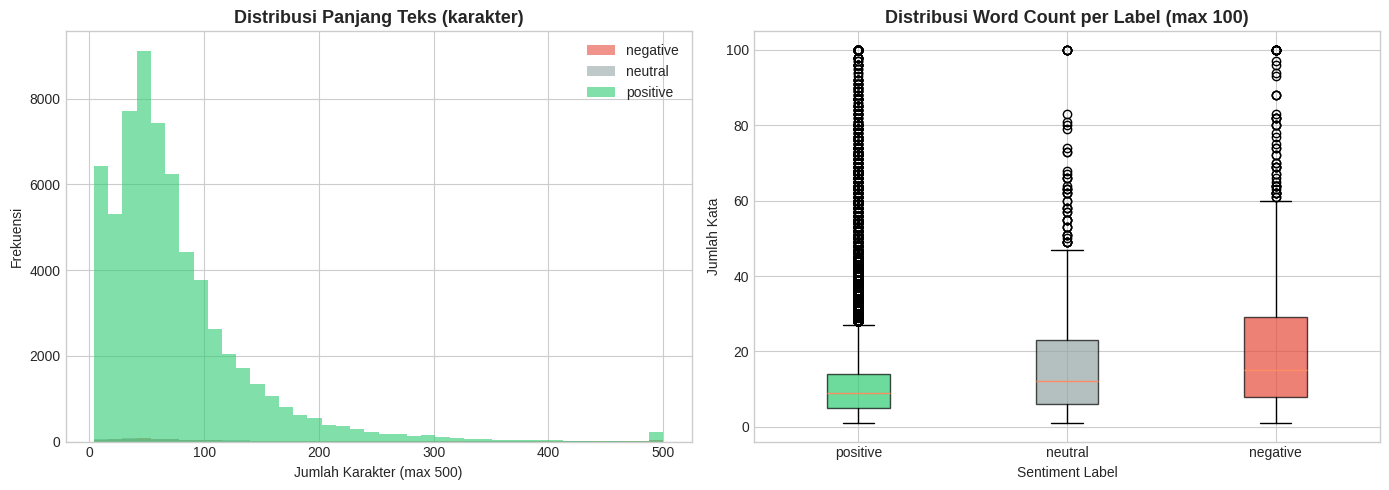

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}

# Histogram text_length (cap di 500 agar tidak terlalu miring)
for label, group in df.groupby('sentiment_label'):
    axes[0].hist(group['text_length'].clip(upper=500), bins=40,
                 alpha=0.6, label=label, color=colors[label])
axes[0].set_title('Distribusi Panjang Teks (karakter)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter (max 500)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot word_count per label
data_to_plot = [df[df['sentiment_label'] == lbl]['word_count'].clip(upper=100)
                for lbl in ['positive', 'neutral', 'negative']]
bp = axes[1].boxplot(data_to_plot, labels=['positive', 'neutral', 'negative'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#95a5a6', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribusi Word Count per Label (max 100)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Jumlah Kata')

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

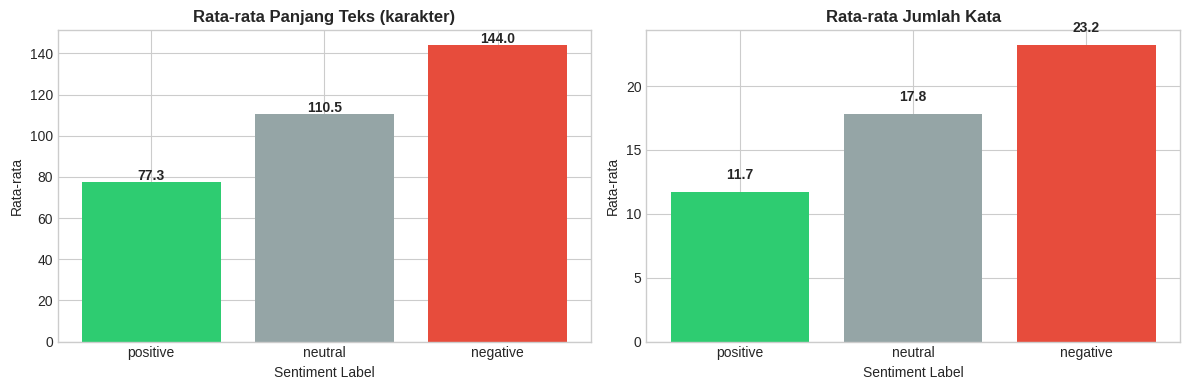

In [16]:
avg_stats = df.groupby('sentiment_label')[['text_length', 'word_count']].mean().round(1)
avg_stats = avg_stats.reindex(['positive', 'neutral', 'negative'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                           ['text_length', 'word_count'],
                           ['Rata-rata Panjang Teks (karakter)', 'Rata-rata Jumlah Kata']):
    bar_colors = ['#2ecc71', '#95a5a6', '#e74c3c']
    bars = ax.bar(avg_stats.index, avg_stats[col], color=bar_colors)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sentiment Label')
    ax.set_ylabel('Rata-rata')
    for bar, val in zip(bars, avg_stats[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('avg_text_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Review dengan teks sangat pendek (≤ 10 karakter) — indikasi fake/spam
very_short = df[df['text_length'] <= 10]

print(f"=== Review Sangat Pendek (≤ 10 karakter) ===")
print(f"Jumlah  : {len(very_short):,} ({len(very_short)/len(df)*100:.2f}%)")
print(f"\nDistribusi label-nya:")
print(very_short['sentiment_label'].value_counts())
print(f"\nContoh review sangat pendek:")
print(very_short['review_text'].head(10).tolist())

=== Review Sangat Pendek (≤ 10 karakter) ===
Jumlah  : 3,697 (5.64%)

Distribusi label-nya:
sentiment_label
positive    3668
neutral       19
negative      10
Name: count, dtype: int64

Contoh review sangat pendek:
['ok mantab', 'Tdk segar', 'pecah 1.', 'Excellent', 'Enak nih👍', 'josh', 'semua oke', 'rasanya ok', '👍👍👍😋😋😋🥳😄😃', '👍👍👍😋😋😋']


## Wordcloud & Frekuensi Kata

In [18]:
from nltk.corpus import stopwords
import string

# Stopwords bahasa Indonesia + Inggris
stop_id = set([
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'tidak', 'ada', 'sudah', 'saya', 'nya', 'lebih', 'juga', 'bisa',
    'karena', 'sangat', 'sekali', 'sih', 'aja', 'deh', 'dong', 'yg',
    'dgn', 'utk', 'dr', 'tp', 'tapi', 'klo', 'kalau', 'ya', 'ga',
    'gak', 'nggak', 'udah', 'udh', 'lah', 'kah', 'pun', 'nya', 'ku',
    'mu', 'kok', 'si', 'pak', 'bu', 'mas', 'mba', 'bang', 'kak',
    'nih', 'dg', 'sy', 'lg', 'jg', 'sdh', 'blm', 'krn', 'pd', 'org'
])
stop_en = set(stopwords.words('english'))
all_stopwords = stop_id | stop_en

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # hapus URL
    text = re.sub(r'[^\w\s]', ' ', text)              # hapus tanda baca
    text = re.sub(r'\d+', '', text)                   # hapus angka
    text = re.sub(r'\s+', ' ', text).strip()          # rapikan spasi
    tokens = text.split()
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['review_text'].apply(clean_text)

print("=== Contoh Hasil Cleaning ===")
for i in range(3):
    print(f"\nOriginal : {df['review_text'].iloc[i][:80]}")
    print(f"Cleaned  : {df['clean_text'].iloc[i][:80]}")

=== Contoh Hasil Cleaning ===

Original : baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. se
Cleaned  : baru terima brg belanja online packing super rapih aman semula ragu bagaimana mu

Original : cocok bgt aku sama telur nya. nga Amis menurutku dan nga neg jadi nya. diterima 
Cleaned  : cocok bgt aku sama telur nga amis menurutku nga neg jadi diterima baik aman teri

Original : Telornya sudah sampai di rumah dengan kemasan yang sangat rapi, luar biasa. Teri
Cleaned  : telornya sampai rumah kemasan rapi luar biasa terimakasih buat sellernya mantaps


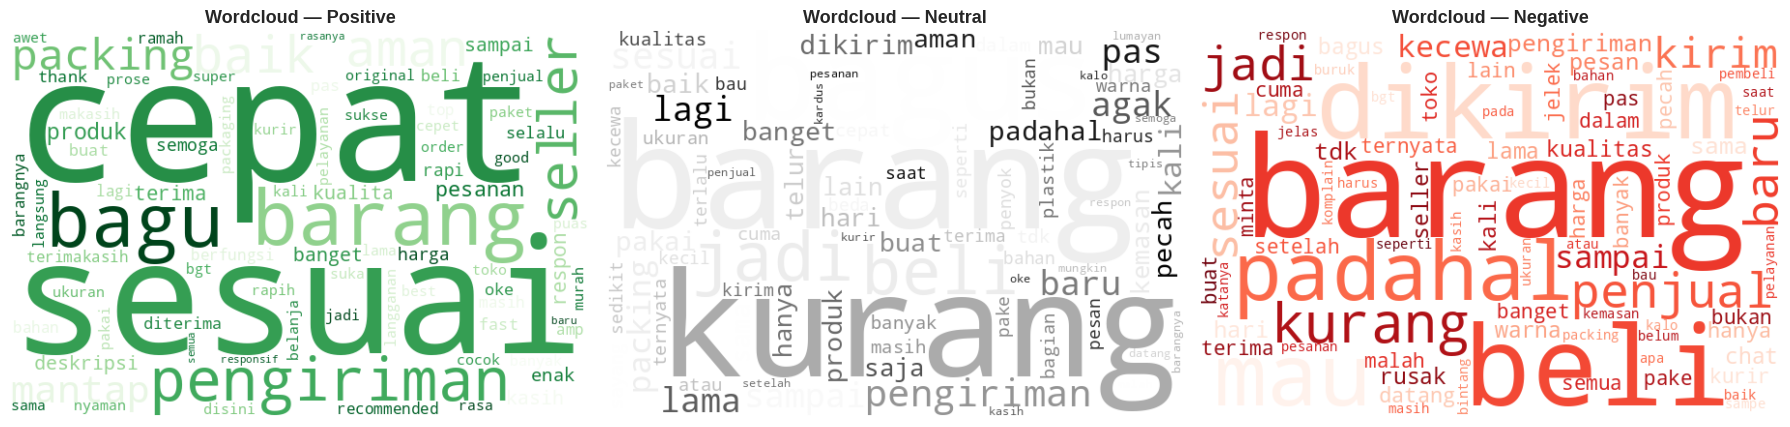

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

label_color = {
    'positive': 'Greens',
    'neutral':  'Greys',
    'negative': 'Reds'
}

for ax, label in zip(axes, ['positive', 'neutral', 'negative']):
    text_corpus = ' '.join(df[df['sentiment_label'] == label]['clean_text'])

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=label_color[label],
        max_words=80,
        collocations=False
    ).generate(text_corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Wordcloud — {label.capitalize()}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud_per_label.png', dpi=150, bbox_inches='tight')
plt.show()

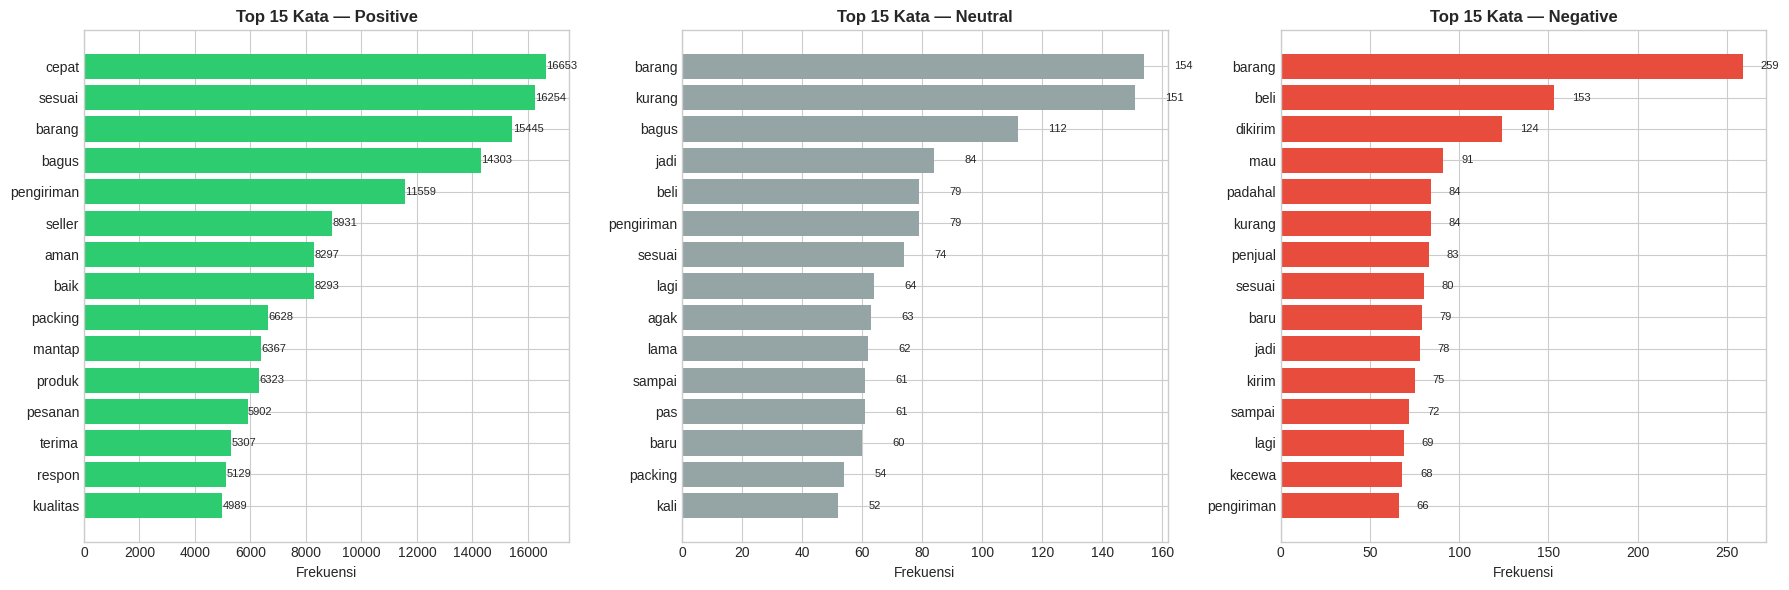

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bar_colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}

for ax, label in zip(axes, ['positive', 'neutral', 'negative']):
    text_corpus = ' '.join(df[df['sentiment_label'] == label]['clean_text'])
    word_freq = Counter(text_corpus.split()).most_common(15)
    words, freqs = zip(*word_freq)

    bars = ax.barh(list(words)[::-1], list(freqs)[::-1], color=bar_colors[label])
    ax.set_title(f'Top 15 Kata — {label.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    for bar, val in zip(bars, list(freqs)[::-1]):
        ax.text(val + 10, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('top_words_per_label.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
def get_top_words(label, n=200):
    corpus = ' '.join(df[df['sentiment_label'] == label]['clean_text'])
    return set([w for w, _ in Counter(corpus.split()).most_common(n)])

top_positive = get_top_words('positive', 300)
top_negative = get_top_words('negative', 300)

exclusive_negative = top_negative - top_positive
exclusive_positive = top_positive - top_negative

print("=== Kata Eksklusif di NEGATIVE (tidak muncul di top positive) ===")
print(sorted(exclusive_negative))

print("\n=== Kata Eksklusif di POSITIVE (tidak muncul di top negative) ===")
print(sorted(list(exclusive_positive)[:30]))  # tampilkan 30 saja

=== Kata Eksklusif di NEGATIVE (tidak muncul di top positive) ===
['akhirnya', 'alasan', 'anda', 'ayam', 'beda', 'begini', 'begitu', 'beras', 'biasanya', 'bilang', 'biru', 'bola', 'bolong', 'botol', 'box', 'buka', 'bulan', 'bungkus', 'buruk', 'busuk', 'butir', 'cancel', 'cara', 'cek', 'chat', 'cuman', 'dateng', 'dia', 'dibuka', 'dtg', 'dua', 'frozen', 'ganti', 'gimana', 'gini', 'gitu', 'habis', 'hampir', 'hancur', 'harusnya', 'hasil', 'hati', 'hijau', 'hitam', 'ikan', 'info', 'jangan', 'jawab', 'jelas', 'jelek', 'jika', 'jual', 'jualan', 'jujur', 'kan', 'kantong', 'kapok', 'kartu', 'katanya', 'kaya', 'kayak', 'kecewa', 'keluar', 'kenapa', 'keras', 'kita', 'komplain', 'konfirmasi', 'kosong', 'kulit', 'lainnya', 'lalu', 'lemak', 'lepas', 'lihat', 'maaf', 'mahal', 'malah', 'mana', 'masalah', 'masuk', 'mengecewakan', 'merah', 'minggu', 'minta', 'namun', 'ngga', 'nyala', 'official', 'oleh', 'online', 'orang', 'parah', 'pasang', 'pcs', 'pdhl', 'pembeli', 'pihak', 'potong', 'potongan', 'putih

## Insight & Korelasi

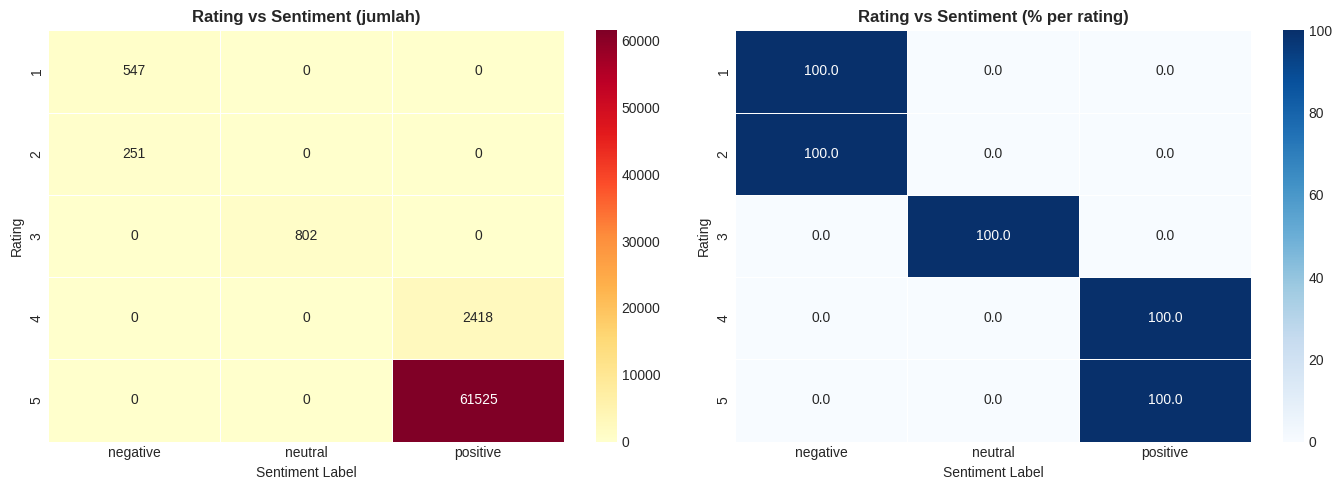

In [24]:
cross = pd.crosstab(df['rating'], df['sentiment_label'])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100  # dalam persen per rating

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap absolut
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Rating vs Sentiment (jumlah)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Rating')

# Heatmap persentase
sns.heatmap(cross_pct.round(1), annot=True, fmt='.1f', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Rating vs Sentiment (% per rating)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.savefig('rating_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

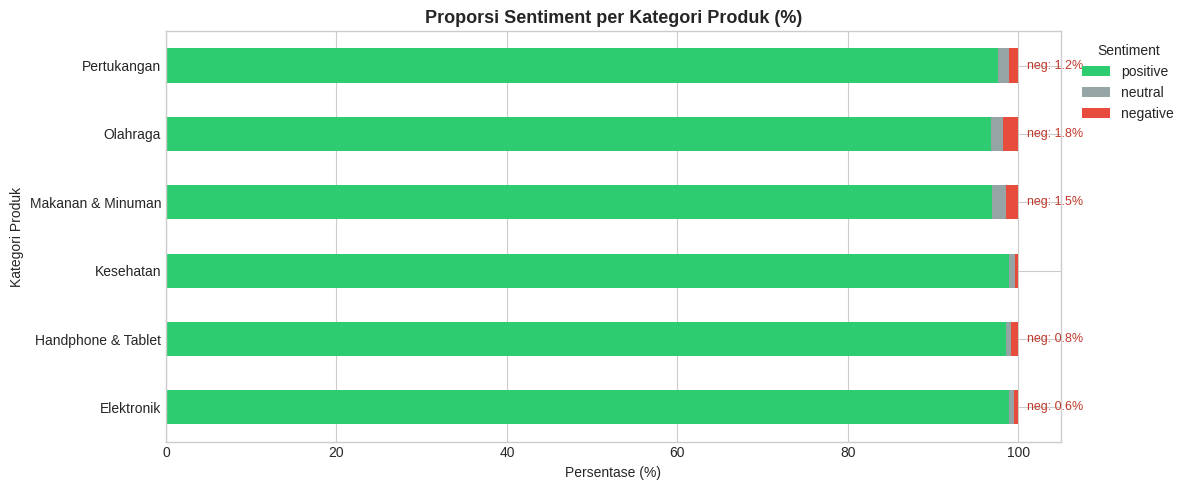


=== % Negative per Kategori ===
product_category
Olahraga              1.78
Makanan & Minuman     1.47
Pertukangan           1.16
Handphone & Tablet    0.84
Elektronik            0.57
Kesehatan             0.44
Name: negative, dtype: float64


In [27]:
cat_sentiment = pd.crosstab(df['product_category'], df['sentiment_label'])
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100

# Stacked bar chart
ax = cat_sentiment_pct[['positive', 'neutral', 'negative']].plot(
    kind='barh', stacked=True, figsize=(12, 5),
    color=['#2ecc71', '#95a5a6', '#e74c3c']
)
ax.set_title('Proporsi Sentiment per Kategori Produk (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Persentase (%)')
ax.set_ylabel('Kategori Produk')
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')

# Tambah label persentase negative
for i, (idx, row) in enumerate(cat_sentiment_pct.iterrows()):
    neg_pct = row.get('negative', 0)
    if neg_pct > 0.5:
        ax.text(101, i, f"neg: {neg_pct:.1f}%", va='center', fontsize=9, color='#c0392b')

plt.tight_layout()
plt.savefig('sentiment_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== % Negative per Kategori ===")
print(cat_sentiment_pct['negative'].sort_values(ascending=False).round(2))

In [28]:
# Review dengan teks identik
duplicates = df[df.duplicated(subset='review_text', keep=False)]
dup_clean = df[df.duplicated(subset='clean_text', keep=False)]

print(f"=== Analisis Duplikat ===")
print(f"Review teks identik      : {len(duplicates):,} ({len(duplicates)/len(df)*100:.2f}%)")
print(f"Review teks bersih identik: {len(dup_clean):,} ({len(dup_clean)/len(df)*100:.2f}%)")

print(f"\n=== Distribusi label dari review duplikat ===")
print(duplicates['sentiment_label'].value_counts())

print(f"\n=== Contoh teks yang paling sering duplikat ===")
top_dup = df['review_text'].value_counts().head(5)
for text, count in top_dup.items():
    print(f"\n[{count}x] '{text[:80]}'")

=== Analisis Duplikat ===
Review teks identik      : 10,351 (15.79%)
Review teks bersih identik: 13,733 (20.95%)

=== Distribusi label dari review duplikat ===
sentiment_label
positive    10291
neutral        39
negative       21
Name: count, dtype: int64

=== Contoh teks yang paling sering duplikat ===

[323x] 'Bagus'

[288x] 'mantap'

[226x] 'bagus'

[193x] 'Mantap'

[127x] 'Good'


In [30]:
summary = {
    'Total Review'               : f"{len(df):,}",
    'Label Positive'             : f"{(df['sentiment_label']=='positive').sum():,} (97.56%)",
    'Label Neutral'              : f"{(df['sentiment_label']=='neutral').sum():,} (1.22%)",
    'Label Negative'             : f"{(df['sentiment_label']=='negative').sum():,} (1.22%)",
    'Missing (product_variant)'  : "38,794 (59.19%)",
    'Review sangat pendek (≤10)' : f"{(df['text_length']<=10).sum():,} — 99% positive",
    'Avg panjang teks - positive': f"{df[df['sentiment_label']=='positive']['text_length'].mean():.1f} karakter",
    'Avg panjang teks - negative': f"{df[df['sentiment_label']=='negative']['text_length'].mean():.1f} karakter",
    'Kategori produk terbanyak'  : "Makanan & Minuman (17,859)",
}

print("=" * 55)
print("       RINGKASAN EDA — FAKE REVIEW DETECTOR")
print("=" * 55)
for k, v in summary.items():
    print(f"  {k:<32}: {v}")
print("=" * 55)

       RINGKASAN EDA — FAKE REVIEW DETECTOR
  Total Review                    : 65,543
  Label Positive                  : 63,943 (97.56%)
  Label Neutral                   : 802 (1.22%)
  Label Negative                  : 798 (1.22%)
  Missing (product_variant)       : 38,794 (59.19%)
  Review sangat pendek (≤10)      : 3,697 — 99% positive
  Avg panjang teks - positive     : 77.3 karakter
  Avg panjang teks - negative     : 144.0 karakter
  Kategori produk terbanyak       : Makanan & Minuman (17,859)


## Kesimpulan EDA

In [32]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           KESIMPULAN EDA — FAKE REVIEW DETECTOR                  ║
║                  Dataset: Tokopedia 2025                         ║
╚══════════════════════════════════════════════════════════════════╝

 1. GAMBARAN UMUM DATASET
   • Total review  : 65.543
   • Kolom         : 13 (6 numerik, 7 teks/kategorik)
   • Missing values: hanya product_variant (59.19%) — bisa diabaikan

  2. CLASS IMBALANCE — KRITIS
   • Positive : 63.943 (97.56%)
   • Neutral  :    802  (1.22%)
   • Negative :    798  (1.22%)
   → Dataset sangat imbalanced. Model harus menggunakan teknik
     oversampling (SMOTE) atau class_weight saat training.

  3. LABEL BERASAL DARI RATING, BUKAN TEKS
   • Rating 1-2 → negative (100%), Rating 3 → neutral (100%),
     Rating 4-5 → positive (100%)
   → sentiment_label bukan hasil analisis NLP, melainkan rule-based
     dari rating. Perlu dipertimbangkan apakah label ini cukup
     representatif untuk fake review detection.

  4. PANJANG TEKS BERBEDA ANTAR LABEL
   • Negative : rata-rata 143.98 karakter (2x lebih panjang)
   • Neutral  : rata-rata 110.49 karakter
   • Positive : rata-rata  77.34 karakter
   → Panjang teks bisa menjadi fitur penting di model.

  5. INDIKASI FAKE REVIEW
   a) Review sangat pendek (≤10 karakter): 3.697 review (5.64%)
      — 99.2% berlabel positive
      — Contoh: 'Bagus', 'ok', hanya emoji '👍👍👍'
   b) Review duplikat identik: 10.351 review (15.79%)
      — 99.4% berlabel positive
      — 'Bagus' muncul 323x, 'mantap' 288x, 'Good' 127x
   c) Review bersih duplikat: 13.733 review (20.95%)
   → ~1 dari 5 review terindikasi tidak autentik.

  6. DISTRIBUSI KATEGORI PRODUK
   • Terbanyak : Makanan & Minuman (17.859), Olahraga (15.600)
   • Negative terbanyak: Olahraga (1.78%), Makanan & Minuman (1.47%)

  7. KATA KUNCI PER LABEL
   • Positive  : cepat, sesuai, packing, seller, pengiriman
     → Banyak kata generik → berpotensi template/fake
   • Negative  : kecewa, rusak, pecah, padahal, kurang, jelek
     → Kata spesifik & kontekstual → lebih autentik
   • Kata eksklusif negative: refund, retur, cancel, komplain,
     kapok, mengecewakan, hancur, busuk → fitur kuat untuk model

  8. REKOMENDASI UNTUK MODELLING
   1. Tangani class imbalance dengan oversampling / class_weight
   2. Gunakan text_length & word_count sebagai fitur tambahan
   3. Flag review duplikat & sangat pendek sebagai sinyal fake
   4. Pertimbangkan re-labelling berbasis teks (bukan rating)
   5. Kata eksklusif negative bisa jadi fitur lexicon-based
""")


╔══════════════════════════════════════════════════════════════════╗
║           KESIMPULAN EDA — FAKE REVIEW DETECTOR                  ║
║                  Dataset: Tokopedia 2025                         ║
╚══════════════════════════════════════════════════════════════════╝

 1. GAMBARAN UMUM DATASET
   • Total review  : 65.543
   • Kolom         : 13 (6 numerik, 7 teks/kategorik)
   • Missing values: hanya product_variant (59.19%) — bisa diabaikan

  2. CLASS IMBALANCE — KRITIS
   • Positive : 63.943 (97.56%)
   • Neutral  :    802  (1.22%)
   • Negative :    798  (1.22%)
   → Dataset sangat imbalanced. Model harus menggunakan teknik
     oversampling (SMOTE) atau class_weight saat training.

  3. LABEL BERASAL DARI RATING, BUKAN TEKS
   • Rating 1-2 → negative (100%), Rating 3 → neutral (100%),
     Rating 4-5 → positive (100%)
   → sentiment_label bukan hasil analisis NLP, melainkan rule-based
     dari rating. Perlu dipertimbangkan apakah label ini cukup
     representatif untuk 